In [2]:
import pandas as pd
GDP_by_state_int = pd.read_csv('GDPstate.csv')
GDP_by_state_int.set_index('State1', inplace=True)
del GDP_by_state_int['2022(duplicate)']
del GDP_by_state_int['2015']
del GDP_by_state_int['2016']
del GDP_by_state_int['2017']
del GDP_by_state_int['2021']
del GDP_by_state_int['2022']
del GDP_by_state_int['2023']
GDP_by_state_int.head()

,2014Q3,2014Q4,2015Q1,2015Q2,2015Q3,2015Q4,2016Q1,2016Q2,2016Q3,2016Q4,...,2022Q3,2023Q1,2023Q2,2023Q3,2024Q1,2024Q2,2024Q3,2021Q4,2022Q4,2023Q4
State1,,,,,,,,,,,,,,,,,,,,,
United States1,4351576.5,4374944.50,4416845.00,4470359.75,4506166.25,4526278.25,4553110.00,4606297.50,4654005.00,4698089.00,...,6430985.25,6703400.25,6765753.00,6902532.00,7156017.25,7254178.50,7343728.50,6319698.75,6815883.75,7349023.75
New England,230235.5,232825.75,234686.50,238172.75,239385.00,242882.50,244884.75,246947.00,249654.00,249331.25,...,330297.25,341723.50,345571.00,352436.00,366795.75,371235.50,376008.00,326744.25,339485.50,370956.50
Connecticut,63066.5,63308.75,62349.25,63185.25,63416.50,63978.50,64722.25,65001.50,65124.25,65070.50,...,80956.25,83377.00,84115.50,85796.50,89648.50,90854.25,92080.25,79065.25,79578.75,92623.00
Maine,13648.0,13875.75,13951.50,14288.00,14434.50,14622.50,14650.50,14833.75,14877.50,14933.00,...,21296.75,22327.50,22512.75,22954.50,24215.00,24468.00,24809.50,21700.00,23037.75,25475.25
Massachusetts,114733.5,116307.75,119185.50,120966.50,121203.00,123588.00,124500.25,125708.50,127759.00,127807.75,...,173282.75,179249.25,181666.25,185335.75,191839.75,194036.75,196285.25,170755.00,179903.75,190044.75


In [3]:
GDP_by_state = GDP_by_state_int.transpose()
GDP_by_state.head()

State1,United States1,New England,Connecticut,Maine,Massachusetts,New Hampshire,Rhode Island,Vermont,Mideast,Delaware,...,Montana,Utah,Wyoming,Far West,Alaska,California,Hawaii,Nevada,Oregon,Washington
2014Q3,4351576.50,230235.50,63066.50,13648.00,114733.50,17695.75,13696.50,7395.25,790502.25,16159.25,...,11142.50,35248.00,11095.75,810319.25,14136.50,582699.00,19159.50,34032.50,53959.75,106332.00
2014Q4,4374944.50,232825.75,63308.75,13875.75,116307.75,17945.75,13896.25,7491.50,795930.50,16040.50,...,11138.75,35681.75,10894.25,815479.75,13956.00,585310.25,19240.25,34548.75,54341.25,108083.25
2015Q1,4416845.00,234686.50,62349.25,13951.50,119185.50,17986.00,13789.00,7425.25,804149.25,16981.50,...,11187.50,36195.75,10041.25,839581.50,13341.00,609696.75,19789.75,34175.50,53328.75,109249.50
2015Q2,4470359.75,238172.75,63185.25,14288.00,120966.50,18329.50,13950.25,7453.25,816360.75,17187.75,...,11448.75,36686.25,10176.00,852259.50,13478.75,618956.50,20007.00,34801.75,53930.00,111085.50
2015Q3,4506166.25,239385.00,63416.50,14434.50,121203.00,18647.50,14093.50,7590.00,823232.50,17260.75,...,11385.50,37124.50,10023.50,858985.50,13123.25,623212.75,20193.25,35297.50,55018.50,112140.50


In [4]:
# I want quarterly data, but also by area, so I will add new columns to represent the regions:
# West is California, Oregon, Washington, Idaho, Montana, Wyoming, Nevada, Utah, Colorado, Arizona, New Mexico,
# Hawaii, and Alaska.
# Midwest is North Dakota, South Dakota, Nebraska, Kansas, Minnesota, Iowa, Missouri, Wisconsin, Illinois,
# Indiana, Michigan, and Ohio.
# South is Texas, Oklahoma, Arkansas, Louisiana, Mississippi, Kentucky, Tennessee, Alabama, Georgia, Florida,
# South Carolina, North Carolina, Virginia, West Virginia, Maryland, Delaware, and the District of Columbia
# (however, there is no District of Columbia in the next data set, so I will leave it out).
# Northeast is Pennsylvania, New York, Maine, Vermont, New Hampshire, Maryland, Rhode Island, Connecticut, 
# and New Jersey.
# This is just the total GDP of the area, so I don't need to adjust by population or take an average.

# Have to get rid of the spaces at the end of each state name first.

GDP_by_state.columns = GDP_by_state.columns.str.rstrip()

GDP_by_state['GDP_West'] = GDP_by_state['California']+GDP_by_state['Oregon']+GDP_by_state['Washington']+\
                       GDP_by_state['Idaho']+GDP_by_state['Montana']+GDP_by_state['Wyoming']+\
                       GDP_by_state['Nevada']+GDP_by_state['Utah']+GDP_by_state['Colorado']+\
                       GDP_by_state['Arizona']+GDP_by_state['New Mexico']+GDP_by_state['Hawaii']+\
                       GDP_by_state['Alaska']

GDP_by_state['GDP_Midwest'] = GDP_by_state['North Dakota']+GDP_by_state['South Dakota']+GDP_by_state['Nebraska']+\
                          GDP_by_state['Kansas']+GDP_by_state['Minnesota']+GDP_by_state['Iowa']+\
                          GDP_by_state['Missouri']+GDP_by_state['Wisconsin']+GDP_by_state['Illinois']+\
                          GDP_by_state['Indiana']+GDP_by_state['Michigan']+GDP_by_state['Ohio']

GDP_by_state['GDP_South'] = GDP_by_state['Texas']+GDP_by_state['Oklahoma']+GDP_by_state['Arkansas']+\
                        GDP_by_state['Louisiana']+GDP_by_state['Mississippi']+GDP_by_state['Kentucky']+\
                        GDP_by_state['Tennessee']+GDP_by_state['Alabama']+GDP_by_state['Georgia']+\
                        GDP_by_state['Florida']+GDP_by_state['South Carolina']+GDP_by_state['North Carolina']+\
                        GDP_by_state['Virginia']+GDP_by_state['West Virginia']+GDP_by_state['Maryland']+\
                        GDP_by_state['Delaware']

GDP_by_state['GDP_Northeast'] = GDP_by_state['Pennsylvania']+GDP_by_state['New York']+GDP_by_state['Maine']+\
                            GDP_by_state['Vermont']+GDP_by_state['New Hampshire']+GDP_by_state['Maryland']+\
                            GDP_by_state['Rhode Island']+GDP_by_state['Connecticut']+GDP_by_state['New Jersey']

GDP_by_state['GDP_United States'] = GDP_by_state['United States1']

In [5]:
# Now make a new data frame just including these columns

GDP_by_region = GDP_by_state[['GDP_United States','GDP_West','GDP_Midwest','GDP_South','GDP_Northeast']]
GDP_by_region.head()

State1,GDP_United States,GDP_West,GDP_Midwest,GDP_South,GDP_Northeast
2014Q3,4351576.50,1056614.75,881723.00,1496238.00,860713.00
2014Q4,4374944.50,1063618.75,886325.75,1500014.25,867130.25
2015Q1,4416845.00,1085371.00,901179.00,1498682.00,872507.25
2015Q2,4470359.75,1101386.25,910384.25,1512092.00,885825.00
2015Q3,4506166.25,1109390.25,919929.75,1523030.25,893511.00


In [6]:
GDP_by_region.index = pd.to_datetime(GDP_by_region.index)
GDP_by_region
# Note that some values at the end are not in date order, so I need to sort them.

C:\Users\jabbe\AppData\Local\Temp\ipykernel_25492\1983609544.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  GDP_by_region.index = pd.to_datetime(GDP_by_region.index)


State1,GDP_United States,GDP_West,GDP_Midwest,GDP_South,GDP_Northeast
2014-07-01,4351576.50,1.056615e+06,8.817230e+05,1.496238e+06,8.607130e+05
2014-10-01,4374944.50,1.063619e+06,8.863258e+05,1.500014e+06,8.671302e+05
2015-01-01,4416845.00,1.085371e+06,9.011790e+05,1.498682e+06,8.725072e+05
2015-04-01,4470359.75,1.101386e+06,9.103842e+05,1.512092e+06,8.858250e+05
2015-07-01,4506166.25,1.109390e+06,9.199298e+05,1.523030e+06,8.935110e+05
2015-10-01,4526278.25,1.117234e+06,9.256692e+05,1.527000e+06,8.947278e+05
2016-01-01,4553110.00,1.137880e+06,9.262662e+05,1.521954e+06,9.047042e+05
2016-04-01,4606297.50,1.152171e+06,9.375755e+05,1.540491e+06,9.139832e+05
2016-07-01,4654005.00,1.168951e+06,9.470198e+05,1.556332e+06,9.184740e+05
2016-10-01,4698089.00,1.183426e+06,9.555690e+05,1.571347e+06,9.255360e+05


In [61]:
# It won't let me sort them even though the index is a datetime object, but I think it doesn't matter because
# they sorted themselves properly when I combined the data later anyway.
# Next I'll import the unemployment rate data.
UR_by_state = pd.read_csv('URstate.csv')
UR_by_state.set_index('date', inplace=True)
UR_by_state.head()

,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
date,,,,,,,,,,,,,,,,,,,,,
1976-01-01,6.600000,7.066667,10.166667,7.300000,9.166667,5.733333,9.800000,8.000000,9.666667,8.400000,...,3.266667,6.000000,5.833333,5.833333,8.600000,6.100000,8.466667,7.500000,5.766667,4.100000
1976-04-01,6.466667,6.966667,9.833333,7.066667,9.033333,5.600000,9.433333,8.333333,9.333333,8.133333,...,3.100000,5.933333,5.900000,5.700000,8.500000,5.900000,8.533333,7.433333,5.500000,3.900000
1976-07-01,6.700000,7.633333,9.633333,6.700000,9.100000,5.933333,8.966667,8.900000,9.100000,8.000000,...,3.300000,6.066667,5.800000,5.433333,8.166667,5.800000,8.866667,7.066667,5.333333,3.700000
1976-10-01,7.033333,8.600000,9.400000,6.600000,9.300000,6.400000,8.500000,9.166667,9.100000,8.100000,...,3.600000,6.400000,5.733333,5.466667,7.766667,5.666667,9.266667,6.900000,5.433333,3.733333
1977-01-01,7.400000,9.366667,9.200000,6.600000,9.066667,6.600000,7.933333,9.066667,8.966667,7.900000,...,3.700000,6.533333,5.766667,5.500000,7.500000,5.566667,9.333333,7.100000,5.366667,3.700000


In [8]:
# Now I need to do the same thing I did before so simplify this into regions.  I can just find and replace here,
# then divide by the number of states (although it should be adjusted by population of each state in each time
# period).

UR_by_state.columns = UR_by_state.columns.str.rstrip()

UR_by_state['UR_West'] = (UR_by_state['CA']+UR_by_state['OR']+UR_by_state['WA']+\
                          UR_by_state['ID']+UR_by_state['MT']+UR_by_state['WY']+\
                          UR_by_state['NV']+UR_by_state['UT']+UR_by_state['CO']+\
                          UR_by_state['AZ']+UR_by_state['NM']+UR_by_state['HI']+\
                          UR_by_state['AK'])/13

UR_by_state['UR_Midwest'] = (UR_by_state['ND']+UR_by_state['SD']+UR_by_state['NE']+\
                             UR_by_state['KS']+UR_by_state['MN']+UR_by_state['IA']+\
                             UR_by_state['MO']+UR_by_state['WI']+UR_by_state['IL']+\
                             UR_by_state['IN']+UR_by_state['MI']+UR_by_state['OH'])/12

UR_by_state['UR_South'] = (UR_by_state['TX']+UR_by_state['OK']+UR_by_state['AR']+\
                           UR_by_state['LA']+UR_by_state['MS']+UR_by_state['KY']+\
                           UR_by_state['TN']+UR_by_state['AL']+UR_by_state['GA']+\
                           UR_by_state['FL']+UR_by_state['SC']+UR_by_state['NC']+\
                           UR_by_state['VA']+UR_by_state['WV']+UR_by_state['MD']+\
                           UR_by_state['DE'])/16

UR_by_state['UR_Northeast'] = (UR_by_state['PA']+UR_by_state['NY']+UR_by_state['ME']+\
                               UR_by_state['VT']+UR_by_state['NH']+UR_by_state['MD']+\
                               UR_by_state['RI']+UR_by_state['CT']+UR_by_state['NJ'])/9

In [9]:
UR_by_region = UR_by_state[['UR_West','UR_Midwest','UR_South','UR_Northeast']]
UR_by_region.head()

,UR_West,UR_Midwest,UR_South,UR_Northeast
date,,,,
1976-01-01,7.620513,5.605556,6.870833,8.485185
1976-04-01,7.458974,5.447222,6.762500,8.403704
1976-07-01,7.469231,5.375000,6.718750,8.348148
1976-10-01,7.658974,5.458333,6.793750,8.392593
1977-01-01,7.612821,5.400000,6.825000,8.281481


In [63]:
UR_by_region.index = pd.DatetimeIndex(UR_by_region.index)

In [10]:
# Now to import the inflation rate by region

Inflation_by_region_int = pd.read_csv('Inflationregion.csv')
Inflation_by_region_int.columns = Inflation_by_region_int.columns.str.rstrip()
Inflation_by_region_int

,Year,JanNE,FebNE,MarNE,AprNE,MayNE,JunNE,JulNE,AugNE,SepNE,...,JunS,JulS,AugS,SepS,OctS,NovS,DecS,AnnualS,HALF1S,HALF2S
0,2015-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-01-01,0.689156,0.650789,0.557962,0.996981,0.891324,0.727449,0.781753,1.044669,1.250583,...,0.780947,0.678839,0.994984,1.366749,1.506108,1.565389,2.013668,1.105815,0.857513,1.352727
2,2017-01-01,2.516098,2.583944,2.236864,1.925119,1.710826,1.512500,1.349722,1.550803,1.870473,...,1.500184,1.564563,1.854334,2.383912,2.018461,2.064701,1.839422,2.047342,2.140675,1.954556
3,2018-01-01,1.594510,1.735918,1.951955,2.123744,2.488184,2.550755,2.703287,2.665428,2.236320,...,2.706597,2.884250,2.401510,1.665352,2.131620,1.935435,1.525290,2.223991,2.360166,2.089422
4,2019-01-01,1.495492,1.308972,1.695655,1.662832,1.468553,1.572852,1.711996,1.547527,1.445021,...,1.126061,1.425079,1.374356,1.334346,1.335174,1.602159,2.122238,1.453425,1.374771,1.531606
5,2020-01-01,2.332503,2.389897,1.681186,0.838072,0.593526,0.795904,1.096971,1.126972,1.242594,...,0.287204,0.553691,1.087656,1.337432,1.260594,1.160135,1.376527,0.964002,0.797698,1.129050
6,2021-01-01,1.142423,1.242493,2.079030,3.283516,3.874403,4.575387,4.343563,4.398075,4.562563,...,5.842903,5.789582,5.643750,5.755557,6.632820,7.234621,7.407467,5.075632,3.724402,6.412256
7,2022-01-01,6.251021,6.558326,7.263198,7.169366,7.479298,7.625175,7.256153,7.430942,7.237198,...,9.844154,9.351249,8.887945,8.716406,8.113490,7.687807,7.034758,8.576547,8.872584,8.291482
8,2023-01-01,6.041128,5.899764,4.302906,3.836843,3.070585,2.243737,2.626865,2.798064,3.002097,...,3.257175,3.362563,4.111531,4.171997,3.655362,3.439207,3.660242,4.496838,5.284040,3.733377
9,2024-01-01,2.516733,2.433122,3.372927,3.587325,3.906598,3.811329,3.626988,3.391759,3.408319,...,2.886899,2.872722,2.269755,2.142783,2.503390,2.658482,2.762473,2.956933,3.386596,2.534200


In [11]:
#Inflation_by_region_int['NEQ1'] = Inflation_by_region_int[["JanNE","FebNE","MarNE"]].mean()
Inflation_by_region_int['NEQ1'] = (Inflation_by_region_int["JanNE"]+Inflation_by_region_int["FebNE"]+\
                                   Inflation_by_region_int["MarNE"])/3
Inflation_by_region_int['NEQ1']

0          NaN
1     0.632635
2     2.445635
3     1.760794
4     1.500040
5     2.134529
6     1.487982
7     6.690848
8     5.414599
9     2.774261
10         NaN
Name: NEQ1, dtype: float64

In [12]:
# This isn't the right form so I need to reshape it.  
# First, I'll average the months into quarters (using mean made everything NAN so I'm doing it the long way)
Inflation_by_region_int['NEQ1'] = (Inflation_by_region_int["JanNE"]+Inflation_by_region_int["FebNE"]+\
                                   Inflation_by_region_int["MarNE"])/3
Inflation_by_region_int['NEQ2'] = (Inflation_by_region_int["AprNE"]+Inflation_by_region_int["MayNE"]+\
                                   Inflation_by_region_int["JunNE"])/3
Inflation_by_region_int['NEQ3'] = (Inflation_by_region_int["JulNE"]+Inflation_by_region_int["AugNE"]+\
                                   Inflation_by_region_int["SepNE"])/3
Inflation_by_region_int['NEQ4'] = (Inflation_by_region_int["OctNE"]+Inflation_by_region_int["NovNE"]+\
                                   Inflation_by_region_int["DecNE"])/3

Inflation_by_region_int['WQ1'] = (Inflation_by_region_int["JanW"]+Inflation_by_region_int["FebW"]+\
                                   Inflation_by_region_int["MarW"])/3
Inflation_by_region_int['WQ2'] = (Inflation_by_region_int["AprW"]+Inflation_by_region_int["MayW"]+\
                                   Inflation_by_region_int["JunW"])/3
Inflation_by_region_int['WQ3'] = (Inflation_by_region_int["JulW"]+Inflation_by_region_int["AugW"]+\
                                   Inflation_by_region_int["SepW"])/3
Inflation_by_region_int['WQ4'] = (Inflation_by_region_int["OctW"]+Inflation_by_region_int["NovW"]+\
                                   Inflation_by_region_int["DecW"])/3

Inflation_by_region_int['MWQ1'] = (Inflation_by_region_int["JanMW"]+Inflation_by_region_int["FebMW"]+\
                                   Inflation_by_region_int["MarMW"])/3
Inflation_by_region_int['MWQ2'] = (Inflation_by_region_int["AprMW"]+Inflation_by_region_int["MayMW"]+\
                                   Inflation_by_region_int["JunMW"])/3
Inflation_by_region_int['MWQ3'] = (Inflation_by_region_int["JulMW"]+Inflation_by_region_int["AugMW"]+\
                                   Inflation_by_region_int["SepMW"])/3
Inflation_by_region_int['MWQ4'] = (Inflation_by_region_int["OctMW"]+Inflation_by_region_int["NovMW"]+\
                                   Inflation_by_region_int["DecMW"])/3

Inflation_by_region_int['SQ1'] = (Inflation_by_region_int["JanS"]+Inflation_by_region_int["FebS"]+\
                                   Inflation_by_region_int["MarS"])/3
Inflation_by_region_int['SQ2'] = (Inflation_by_region_int["AprS"]+Inflation_by_region_int["MayS"]+\
                                   Inflation_by_region_int["JunS"])/3
Inflation_by_region_int['SQ3'] = (Inflation_by_region_int["JulS"]+Inflation_by_region_int["AugS"]+\
                                   Inflation_by_region_int["SepS"])/3
Inflation_by_region_int['SQ4'] = (Inflation_by_region_int["OctS"]+Inflation_by_region_int["NovS"]+\
                                   Inflation_by_region_int["DecS"])/3

In [13]:
import numpy as np
Inflation_by_region_int = Inflation_by_region_int.replace(np.nan, 0)
Inflation_by_region_int.set_index('Year', inplace=True)

Inflation_by_region_quarterly_int = Inflation_by_region_int[['NEQ1','NEQ2','NEQ3','NEQ4','WQ1','WQ2','WQ3','WQ4',\
                                                             'MWQ1','MWQ2','MWQ3','MWQ4','SQ1','SQ2','SQ3','SQ4']]
Inflation_by_region_quarterly_int

,NEQ1,NEQ2,NEQ3,NEQ4,WQ1,WQ2,WQ3,WQ4,MWQ1,MWQ2,MWQ3,MWQ4,SQ1,SQ2,SQ3,SQ4
Year,,,,,,,,,,,,,,,,
2015-01-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2016-01-01,0.632635,0.871918,1.025668,1.695112,2.096208,1.616445,1.645121,2.370117,0.558103,0.807246,0.687676,1.347692,0.871352,0.844464,1.013524,1.695055
2017-01-01,2.445635,1.716148,1.590332,1.614940,2.883425,2.691180,2.732238,3.049360,2.178802,1.361594,1.434060,1.684519,2.551872,1.736622,1.934270,1.974195
2018-01-01,1.760794,2.387561,2.535012,1.948401,3.121969,3.455378,3.519885,3.287087,1.711241,2.215098,2.148986,1.608938,2.089911,2.628757,2.317037,1.864115
2019-01-01,1.500040,1.568079,1.568181,1.779454,2.513313,2.832762,2.637039,2.781985,1.232886,1.360903,1.451131,1.905722,1.309830,1.439052,1.377927,1.686524
2020-01-01,2.134529,0.742501,1.155512,1.198172,2.820596,1.081312,1.727426,1.356037,1.872593,-0.139420,1.015750,1.071693,1.723367,-0.115558,0.992926,1.265752
2021-01-01,1.487982,3.911102,4.434734,5.764231,1.803053,4.563376,5.171880,6.520491,1.947554,5.435806,5.783525,7.150450,2.178324,5.281725,5.729629,7.091636
2022-01-01,6.690848,7.424613,7.308098,6.456986,8.171902,8.479026,8.234648,7.163248,8.137410,8.853578,8.285740,6.727412,8.429056,9.299705,8.985200,7.612018
2023-01-01,5.414599,3.050389,2.809009,2.612126,5.792096,4.291140,3.767532,3.389506,5.474335,3.671511,3.147398,3.005880,6.208895,4.404511,3.882030,3.584937


In [14]:
Inflation_by_region_quarterly_int.transpose()
Inflation_by_region_quarterly_int=Inflation_by_region_quarterly_int.drop(['2015-01-01','2025-01-01'])
Inflation_by_region_quarterly_int

,NEQ1,NEQ2,NEQ3,NEQ4,WQ1,WQ2,WQ3,WQ4,MWQ1,MWQ2,MWQ3,MWQ4,SQ1,SQ2,SQ3,SQ4
Year,,,,,,,,,,,,,,,,
2016-01-01,0.632635,0.871918,1.025668,1.695112,2.096208,1.616445,1.645121,2.370117,0.558103,0.807246,0.687676,1.347692,0.871352,0.844464,1.013524,1.695055
2017-01-01,2.445635,1.716148,1.590332,1.614940,2.883425,2.691180,2.732238,3.049360,2.178802,1.361594,1.434060,1.684519,2.551872,1.736622,1.934270,1.974195
2018-01-01,1.760794,2.387561,2.535012,1.948401,3.121969,3.455378,3.519885,3.287087,1.711241,2.215098,2.148986,1.608938,2.089911,2.628757,2.317037,1.864115
2019-01-01,1.500040,1.568079,1.568181,1.779454,2.513313,2.832762,2.637039,2.781985,1.232886,1.360903,1.451131,1.905722,1.309830,1.439052,1.377927,1.686524
2020-01-01,2.134529,0.742501,1.155512,1.198172,2.820596,1.081312,1.727426,1.356037,1.872593,-0.139420,1.015750,1.071693,1.723367,-0.115558,0.992926,1.265752
2021-01-01,1.487982,3.911102,4.434734,5.764231,1.803053,4.563376,5.171880,6.520491,1.947554,5.435806,5.783525,7.150450,2.178324,5.281725,5.729629,7.091636
2022-01-01,6.690848,7.424613,7.308098,6.456986,8.171902,8.479026,8.234648,7.163248,8.137410,8.853578,8.285740,6.727412,8.429056,9.299705,8.985200,7.612018
2023-01-01,5.414599,3.050389,2.809009,2.612126,5.792096,4.291140,3.767532,3.389506,5.474335,3.671511,3.147398,3.005880,6.208895,4.404511,3.882030,3.584937
2024-01-01,2.774261,3.768417,3.475689,3.504077,3.370653,3.283317,2.278530,2.339442,2.755044,2.655906,2.610926,2.744302,3.649038,3.126966,2.428420,2.641449


In [15]:
NE_temp = Inflation_by_region_quarterly_int[['NEQ1','NEQ2','NEQ3','NEQ4']]
NE_temp

,NEQ1,NEQ2,NEQ3,NEQ4
Year,,,,
2016-01-01,0.632635,0.871918,1.025668,1.695112
2017-01-01,2.445635,1.716148,1.590332,1.614940
2018-01-01,1.760794,2.387561,2.535012,1.948401
2019-01-01,1.500040,1.568079,1.568181,1.779454
2020-01-01,2.134529,0.742501,1.155512,1.198172
2021-01-01,1.487982,3.911102,4.434734,5.764231
2022-01-01,6.690848,7.424613,7.308098,6.456986
2023-01-01,5.414599,3.050389,2.809009,2.612126
2024-01-01,2.774261,3.768417,3.475689,3.504077


In [16]:
NE_temp.stack().reset_index()

,Year,level_1,0
0,2016-01-01,NEQ1,0.632635
1,2016-01-01,NEQ2,0.871918
2,2016-01-01,NEQ3,1.025668
3,2016-01-01,NEQ4,1.695112
4,2017-01-01,NEQ1,2.445635
5,2017-01-01,NEQ2,1.716148
6,2017-01-01,NEQ3,1.590332
7,2017-01-01,NEQ4,1.614940
8,2018-01-01,NEQ1,1.760794
9,2018-01-01,NEQ2,2.387561


In [17]:
type(NE_temp['NEQ1'])

pandas.core.series.Series

In [18]:
column_names = ['2016Q1','2017Q1','2018Q1','2019Q1','2020Q1','2021Q1','2022Q1','2023Q1','2024Q1',\
                '2016Q2','2017Q2','2018Q2','2019Q2','2020Q2','2021Q2','2022Q2','2023Q2','2024Q2',\
                '2016Q3','2017Q3','2018Q3','2019Q3','2020Q3','2021Q3','2022Q3','2023Q3','2024Q3',\
                '2016Q4','2017Q4','2018Q4','2019Q4','2020Q4','2021Q4','2022Q4','2023Q4','2024Q4']

In [19]:
NE_temp1 = pd.concat([NE_temp['NEQ1'],NE_temp['NEQ2'],NE_temp['NEQ3'],NE_temp['NEQ4']])
NE_temp1.head()

Year
2016-01-01    0.632635
2017-01-01    2.445635
2018-01-01    1.760794
2019-01-01    1.500040
2020-01-01    2.134529
dtype: float64

In [20]:
type(NE_temp1)

pandas.core.series.Series

In [21]:
#NE_temp2 = NE_temp1.transpose()
#NE_temp2

In [22]:
NE_temp2 = NE_temp1.to_frame()
NE_temp2

,0
Year,
2016-01-01,0.632635
2017-01-01,2.445635
2018-01-01,1.760794
2019-01-01,1.500040
2020-01-01,2.134529
2021-01-01,1.487982
2022-01-01,6.690848
2023-01-01,5.414599
2024-01-01,2.774261


In [23]:
NE_temp3 = NE_temp2.transpose()
NE_temp3

Year,2016-01-01,2017-01-01,2018-01-01,2019-01-01,2020-01-01,2021-01-01,2022-01-01,2023-01-01,2024-01-01,2016-01-01,...,2024-01-01,2016-01-01,2017-01-01,2018-01-01,2019-01-01,2020-01-01,2021-01-01,2022-01-01,2023-01-01,2024-01-01
0,0.632635,2.445635,1.760794,1.50004,2.134529,1.487982,6.690848,5.414599,2.774261,0.871918,...,3.475689,1.695112,1.61494,1.948401,1.779454,1.198172,5.764231,6.456986,2.612126,3.504077


In [24]:
NE_temp3.columns = column_names
NE_temp3

,2016Q1,2017Q1,2018Q1,2019Q1,2020Q1,2021Q1,2022Q1,2023Q1,2024Q1,2016Q2,...,2024Q3,2016Q4,2017Q4,2018Q4,2019Q4,2020Q4,2021Q4,2022Q4,2023Q4,2024Q4
0,0.632635,2.445635,1.760794,1.50004,2.134529,1.487982,6.690848,5.414599,2.774261,0.871918,...,3.475689,1.695112,1.61494,1.948401,1.779454,1.198172,5.764231,6.456986,2.612126,3.504077


In [25]:
NE = NE_temp3.transpose()
NE.head()

,0
2016Q1,0.632635
2017Q1,2.445635
2018Q1,1.760794
2019Q1,1.500040
2020Q1,2.134529


In [26]:
NE = NE.rename(columns={0: 'Inflation_NE'})

In [27]:
NE

,Inflation_NE
2016Q1,0.632635
2017Q1,2.445635
2018Q1,1.760794
2019Q1,1.500040
2020Q1,2.134529


In [28]:
# Now let me do the other 3 regions and combine them again.

In [29]:
W_temp = Inflation_by_region_quarterly_int[['WQ1','WQ2','WQ3','WQ4']]
W_temp.stack().reset_index()
W_temp1 = pd.concat([W_temp['WQ1'],W_temp['WQ2'],W_temp['WQ3'],W_temp['WQ4']])
W_temp2 = W_temp1.to_frame()
W_temp3 = W_temp2.transpose()
W_temp3.columns = column_names
W = W_temp3.transpose()
W = W.rename(columns={0: 'Inflation_W'})
W.head()

,Inflation_W
2016Q1,2.096208
2017Q1,2.883425
2018Q1,3.121969
2019Q1,2.513313
2020Q1,2.820596


In [30]:
MW_temp = Inflation_by_region_quarterly_int[['MWQ1','MWQ2','MWQ3','MWQ4']]
MW_temp.stack().reset_index()
MW_temp1 = pd.concat([MW_temp['MWQ1'],MW_temp['MWQ2'],MW_temp['MWQ3'],MW_temp['MWQ4']])
MW_temp2 = MW_temp1.to_frame()
MW_temp3 = MW_temp2.transpose()
MW_temp3.columns = column_names
MW = MW_temp3.transpose()
MW = MW.rename(columns={0: 'Inflation_MW'})
MW.head()

,Inflation_MW
2016Q1,0.558103
2017Q1,2.178802
2018Q1,1.711241
2019Q1,1.232886
2020Q1,1.872593


In [31]:
S_temp = Inflation_by_region_quarterly_int[['SQ1','SQ2','SQ3','SQ4']]
S_temp.stack().reset_index()
S_temp1 = pd.concat([S_temp['SQ1'],S_temp['SQ2'],S_temp['SQ3'],S_temp['SQ4']])
S_temp2 = S_temp1.to_frame()
S_temp3 = S_temp2.transpose()
S_temp3.columns = column_names
S = S_temp3.transpose()
S = S.rename(columns={0: 'Inflation_S'})
S.head()

,Inflation_S
2016Q1,0.871352
2017Q1,2.551872
2018Q1,2.089911
2019Q1,1.309830
2020Q1,1.723367


In [47]:
Inflation_by_region = W['Inflation_W']
Inflation_by_region = pd.concat([Inflation_by_region, MW['Inflation_MW']], axis=1)
Inflation_by_region = pd.concat([Inflation_by_region, NE['Inflation_NE']], axis=1)
Inflation_by_region = pd.concat([Inflation_by_region, S['Inflation_S']], axis=1)

#This worked before but decided not to when I restarted my kernel
#Inflation_by_region['Inflation_W'] = W['Inflation_W']
#Inflation_by_region['Inflation_MW'] = MW['Inflation_MW']
#Inflation_by_region['Inflation_NE'] = NE['Inflation_NE']
#Inflation_by_region['Inflation_S'] = S['Inflation_S']
print(Inflation_by_region)

        Inflation_W  Inflation_MW  Inflation_NE  Inflation_S
2016Q1     2.096208      0.558103      0.632635     0.871352
2017Q1     2.883425      2.178802      2.445635     2.551872
2018Q1     3.121969      1.711241      1.760794     2.089911
2019Q1     2.513313      1.232886      1.500040     1.309830
2020Q1     2.820596      1.872593      2.134529     1.723367
2021Q1     1.803053      1.947554      1.487982     2.178324
2022Q1     8.171902      8.137410      6.690848     8.429056
2023Q1     5.792096      5.474335      5.414599     6.208895
2024Q1     3.370653      2.755044      2.774261     3.649038
2016Q2     1.616445      0.807246      0.871918     0.844464
2017Q2     2.691180      1.361594      1.716148     1.736622
2018Q2     3.455378      2.215098      2.387561     2.628757
2019Q2     2.832762      1.360903      1.568079     1.439052
2020Q2     1.081312     -0.139420      0.742501    -0.115558
2021Q2     4.563376      5.435806      3.911102     5.281725
2022Q2     8.479026     

In [49]:
Inflation_by_region.index = pd.to_datetime(Inflation_by_region.index)

C:\Users\jabbe\AppData\Local\Temp\ipykernel_25492\4236037069.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Inflation_by_region.index = pd.to_datetime(Inflation_by_region.index)


In [51]:
Inflation_by_region

,Inflation_W,Inflation_MW,Inflation_NE,Inflation_S
2016-01-01,2.096208,0.558103,0.632635,0.871352
2017-01-01,2.883425,2.178802,2.445635,2.551872
2018-01-01,3.121969,1.711241,1.760794,2.089911
2019-01-01,2.513313,1.232886,1.500040,1.309830
2020-01-01,2.820596,1.872593,2.134529,1.723367
2021-01-01,1.803053,1.947554,1.487982,2.178324
2022-01-01,8.171902,8.137410,6.690848,8.429056
2023-01-01,5.792096,5.474335,5.414599,6.208895
2024-01-01,3.370653,2.755044,2.774261,3.649038
2016-04-01,1.616445,0.807246,0.871918,0.844464


In [53]:
print(type(UR_by_region))
print(type(Inflation_by_region))
print(type(GDP_by_region))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [67]:
Full_set = GDP_by_region[['GDP_West','GDP_Midwest','GDP_South','GDP_Northeast']]
Full_set.rename(columns={'GDP_West': 'GDP_W','GDP_Midwest': 'GDP_MW','GDP_South': 'GDP_S', \
                         'GDP_Northeast': 'GDP_NE'}, inplace=True)
Full_set['UR_W']          = UR_by_region['UR_West']
Full_set['UR_MW']         = UR_by_region['UR_Midwest']
Full_set['UR_S']          = UR_by_region['UR_South']
Full_set['UR_NE']         = UR_by_region['UR_Northeast']
Full_set['Inflation_W']   = Inflation_by_region['Inflation_W']
Full_set['Inflation_MW']  = Inflation_by_region['Inflation_MW']
Full_set['Inflation_S']   = Inflation_by_region['Inflation_S']
Full_set['Inflation_NE']  = Inflation_by_region['Inflation_NE']

Full_set

C:\Users\jabbe\AppData\Local\Temp\ipykernel_25492\1128489202.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Full_set.rename(columns={'GDP_West': 'GDP_W','GDP_Midwest': 'GDP_MW','GDP_South': 'GDP_S', \


State1,GDP_W,GDP_MW,GDP_S,GDP_NE,UR_W,UR_MW,UR_S,UR_NE,Inflation_W,Inflation_MW,Inflation_S,Inflation_NE
2014-07-01,1.056615e+06,8.817230e+05,1.496238e+06,8.607130e+05,5.623077,4.847222,6.050000,5.729630,NaN,NaN,NaN,NaN
2014-10-01,1.063619e+06,8.863258e+05,1.500014e+06,8.671302e+05,5.402564,4.613889,5.833333,5.496296,NaN,NaN,NaN,NaN
2015-01-01,1.085371e+06,9.011790e+05,1.498682e+06,8.725072e+05,5.228205,4.452778,5.677083,5.270370,NaN,NaN,NaN,NaN
2015-04-01,1.101386e+06,9.103842e+05,1.512092e+06,8.858250e+05,5.135897,4.330556,5.568750,5.040741,NaN,NaN,NaN,NaN
2015-07-01,1.109390e+06,9.199298e+05,1.523030e+06,8.935110e+05,5.012821,4.163889,5.362500,4.770370,NaN,NaN,NaN,NaN
2015-10-01,1.117234e+06,9.256692e+05,1.527000e+06,8.947278e+05,4.917949,4.097222,5.220833,4.592593,NaN,NaN,NaN,NaN
2016-01-01,1.137880e+06,9.262662e+05,1.521954e+06,9.047042e+05,4.920513,4.125000,5.100000,4.462963,2.096208,0.558103,0.871352,0.632635
2016-04-01,1.152171e+06,9.375755e+05,1.540491e+06,9.139832e+05,4.905128,4.138889,5.014583,4.403704,1.616445,0.807246,0.844464,0.871918
2016-07-01,1.168951e+06,9.470198e+05,1.556332e+06,9.184740e+05,4.823077,4.138889,5.014583,4.359259,1.645121,0.687676,1.013524,1.025668
2016-10-01,1.183426e+06,9.555690e+05,1.571347e+06,9.255360e+05,4.687179,4.077778,4.954167,4.259259,2.370117,1.347692,1.695055,1.695112


In [ ]:
# I used GDP_by_region as the 'base' because it is the only one that went in the correct date order, but it has a 
# wrong name for the index that I can't seem to change.  Hopefully it doesn't matter since it's recognized as a
# datetime object.  However, my Inflation_by_region variable is missing a couple data points, so I'm not sure it
# should be corrected or not.  I will correct it if necessary during the visualization portion.

In [72]:
import sqlite3

In [252]:
conn = sqlite3.connect("GDPData")
GDP_by_region.to_sql('GDPData', conn, if_exists = 'append', index = True)

41

In [254]:
df_from_db = pd.read_sql_query('SELECT * FROM GDPData', conn)
print(df_from_db.head())

                 index  GDP_United States    GDP_West  GDP_Midwest  \
0  2014-07-01 00:00:00         4351576.50  1056614.75    881723.00   
1  2014-10-01 00:00:00         4374944.50  1063618.75    886325.75   
2  2015-01-01 00:00:00         4416845.00  1085371.00    901179.00   
3  2015-04-01 00:00:00         4470359.75  1101386.25    910384.25   
4  2015-07-01 00:00:00         4506166.25  1109390.25    919929.75   

    GDP_South  GDP_Northeast  
0  1496238.00      860713.00  
1  1500014.25      867130.25  
2  1498682.00      872507.25  
3  1512092.00      885825.00  
4  1523030.25      893511.00  


In [256]:
conn2 = sqlite3.connect("URData")
UR_by_region.to_sql('URData', conn2, if_exists = 'append', index = True)

196

In [258]:
df_from_db_2 = pd.read_sql_query('SELECT * FROM URData', conn2)
print(df_from_db_2.head())

                  date   UR_West  UR_Midwest  UR_South  UR_Northeast
0  1976-01-01 00:00:00  7.620513    5.605556  6.870833      8.485185
1  1976-04-01 00:00:00  7.458974    5.447222  6.762500      8.403704
2  1976-07-01 00:00:00  7.469231    5.375000  6.718750      8.348148
3  1976-10-01 00:00:00  7.658974    5.458333  6.793750      8.392593
4  1977-01-01 00:00:00  7.612821    5.400000  6.825000      8.281481


In [260]:
conn3 = sqlite3.connect("InflationData")
Inflation_by_region.to_sql('InflationData', conn3, if_exists = 'append', index = True)

36

In [262]:
df_from_db_3 = pd.read_sql_query('SELECT * FROM InflationData', conn3)
print(df_from_db_3.head())

                 index  Inflation_W  Inflation_MW  Inflation_NE  Inflation_S
0  2016-01-01 00:00:00     2.096208      0.558103      0.632635     0.871352
1  2017-01-01 00:00:00     2.883425      2.178802      2.445635     2.551872
2  2018-01-01 00:00:00     3.121969      1.711241      1.760794     2.089911
3  2019-01-01 00:00:00     2.513313      1.232886      1.500040     1.309830
4  2020-01-01 00:00:00     2.820596      1.872593      2.134529     1.723367


In [266]:
# This is three databases, but apparently I want 3 tables in one database?  It wouldn't let me do this before, but
# maybe I understand it better now?

conn = sqlite3.connect('Dataset1')
cursor = conn.cursor()

GDP_by_region.to_sql('Dataset_GDP', conn, if_exists = 'append', index_label = 'date', index = True)

41

In [268]:
df_from_db = pd.read_sql_query('SELECT * FROM Dataset_GDP', conn)
print(df_from_db.head())

                  date  GDP_United States    GDP_West  GDP_Midwest  \
0  2014-07-01 00:00:00         4351576.50  1056614.75    881723.00   
1  2014-10-01 00:00:00         4374944.50  1063618.75    886325.75   
2  2015-01-01 00:00:00         4416845.00  1085371.00    901179.00   
3  2015-04-01 00:00:00         4470359.75  1101386.25    910384.25   
4  2015-07-01 00:00:00         4506166.25  1109390.25    919929.75   

    GDP_South  GDP_Northeast  
0  1496238.00      860713.00  
1  1500014.25      867130.25  
2  1498682.00      872507.25  
3  1512092.00      885825.00  
4  1523030.25      893511.00  


In [148]:
cursor.execute("ALTER TABLE Dataset ADD COLUMN UR_West INTEGER")

In [272]:
#cursor.execute("ALTER TABLE Dataset ADD COLUMN UR_Northeast INTEGER")
#cursor.execute("ALTER TABLE Dataset ADD COLUMN UR_South INTEGER")
#cursor.execute("ALTER TABLE Dataset ADD COLUMN UR_Midwest INTEGER")
#cursor.execute("ALTER Table Dataset ADD COLUMN Inflation_W INTEGER")
#cursor.execute("ALTER Table Dataset ADD COLUMN Inflation_S INTEGER")
#cursor.execute("ALTER Table Dataset ADD COLUMN Inflation_NE INTEGER")
#cursor.execute("ALTER Table Dataset ADD COLUMN Inflation_MW INTEGER")

# Doing it this way ended up in a 'identity matrix' type results, which isn't what I wanted.

In [ ]:
# I finally figured out how to make multiple tables in one database.

In [164]:
UR_by_region.to_sql('Dataset_UR', conn, if_exists = 'append', index_label = 'date', index = True)

196

In [166]:
Inflation_by_region.to_sql('Dataset_Inflation', conn, if_exists = 'append', index_label = 'date', index = True)

36

In [170]:
df_from_db = pd.read_sql_query('SELECT * FROM Dataset_UR', conn)
print(df_from_db)

                    date   UR_West  UR_Midwest  UR_South  UR_Northeast
0    1976-01-01 00:00:00  7.620513    5.605556  6.870833      8.485185
1    1976-04-01 00:00:00  7.458974    5.447222  6.762500      8.403704
2    1976-07-01 00:00:00  7.469231    5.375000  6.718750      8.348148
3    1976-10-01 00:00:00  7.658974    5.458333  6.793750      8.392593
4    1977-01-01 00:00:00  7.612821    5.400000  6.825000      8.281481
..                   ...       ...         ...       ...           ...
191  2023-10-01 00:00:00  3.861538    3.130556  3.464583      3.437037
192  2024-01-01 00:00:00  3.902564    3.100000  3.470833      3.507407
193  2024-04-01 00:00:00  3.856410    3.188889  3.464583      3.440741
194  2024-07-01 00:00:00  3.971795    3.463889  3.566667      3.425926
195  2024-10-01 00:00:00  4.110256    3.550000  3.712500      3.462963

[196 rows x 5 columns]


In [180]:
df_from_db = pd.read_sql_query('SELECT * FROM Dataset_Inflation', conn)
print(df_from_db)

                   date  Inflation_W  Inflation_MW  Inflation_NE  Inflation_S
0   2016-01-01 00:00:00     2.096208      0.558103      0.632635     0.871352
1   2017-01-01 00:00:00     2.883425      2.178802      2.445635     2.551872
2   2018-01-01 00:00:00     3.121969      1.711241      1.760794     2.089911
3   2019-01-01 00:00:00     2.513313      1.232886      1.500040     1.309830
4   2020-01-01 00:00:00     2.820596      1.872593      2.134529     1.723367
5   2021-01-01 00:00:00     1.803053      1.947554      1.487982     2.178324
6   2022-01-01 00:00:00     8.171902      8.137410      6.690848     8.429056
7   2023-01-01 00:00:00     5.792096      5.474335      5.414599     6.208895
8   2024-01-01 00:00:00     3.370653      2.755044      2.774261     3.649038
9   2016-04-01 00:00:00     1.616445      0.807246      0.871918     0.844464
10  2017-04-01 00:00:00     2.691180      1.361594      1.716148     1.736622
11  2018-04-01 00:00:00     3.455378      2.215098      2.387561

In [188]:
# OK finally got the tables set up, let's join them.
#cursor.execute("""SELECT Dataset_GDP.GDP_West, Dataset_GDP.GDP_South, Dataset_GDP.GDP_Midwest, \
#                Dataset_GDP.GDP_Northeast, Dataset_GDP.date, Dataset_UR.UR_West, Dataset_UR.UR_Northeast, \
#                Dataset_UR.UR_Midwest, Dataset_UR.UR_South, Dataset_UR.date, Dataset_Inflation.Inflation_W, \
#                Dataset_Inflation.Inflation_S, Dataset_Inflation.Inflation_NE, Dataset_Inflation.Inflation_MW \
#                Dataset_Inflation.date
#               FROM Dataset_GDP
#               INNER JOIN Dataset_UR
#               ON Dataset_GDP.date=Dataset_UR.date
#               FROM Dataset_GDP
#               INNER JOIN Dataset_Inflation
#               ON Dataset_GDP.date=Dataset_Inflation.date""") 

# That didn't work, let's try something else.

In [274]:
query = """
SELECT 
    Dataset_GDP.*, 
    Dataset_UR.*,
    Dataset_Inflation.*
FROM 
    Dataset_GDP
JOIN 
    Dataset_UR
ON 
    Dataset_GDP.date = Dataset_UR.date
JOIN
    Dataset_Inflation
On
    Dataset_GDP.date = Dataset_Inflation.date
"""

df = pd.read_sql(query, conn)
print(df.head())

                  date  GDP_United States      GDP_West    GDP_Midwest  \
0  2016-01-01 00:00:00          4553110.0  1.137880e+06  926266.250000   
1  2016-04-01 00:00:00          4606297.5  1.152171e+06  937575.500000   
2  2016-07-01 00:00:00          4654005.0  1.168951e+06  947019.750000   
3  2016-10-01 00:00:00          4698089.0  1.183426e+06  955569.000000   
4  2017-01-01 00:00:00          4790637.5  1.207327e+06  954681.686518   

      GDP_South  GDP_Northeast                 date   UR_West  UR_Midwest  \
0  1.521954e+06  904704.250000  2016-01-01 00:00:00  4.920513    4.125000   
1  1.540491e+06  913983.250000  2016-04-01 00:00:00  4.905128    4.138889   
2  1.556332e+06  918474.000000  2016-07-01 00:00:00  4.823077    4.138889   
3  1.571347e+06  925536.000000  2016-10-01 00:00:00  4.687179    4.077778   
4  1.580451e+06  951496.913242  2017-01-01 00:00:00  4.448718    3.816667   

   UR_South  UR_Northeast                 date  Inflation_W  Inflation_MW  \
0  5.100000    

In [212]:
import matplotlib.pyplot as plt

In [213]:
print(df.columns.tolist())

['date', 'GDP_United States', 'GDP_West', 'GDP_Midwest', 'GDP_South', 'GDP_Northeast', 'date', 'UR_West', 'UR_Midwest', 'UR_South', 'UR_Northeast', 'date', 'Inflation_W', 'Inflation_MW', 'Inflation_NE', 'Inflation_S']


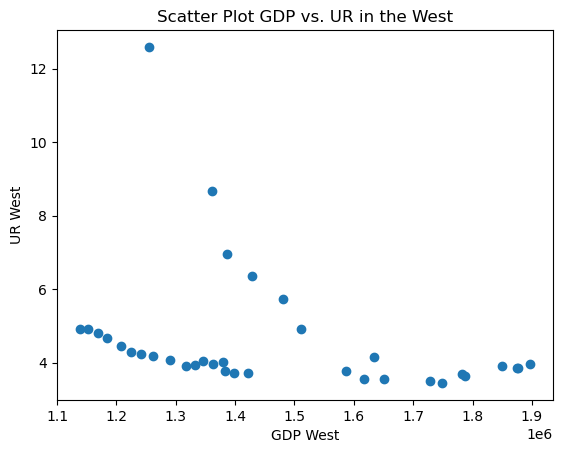

In [216]:
# I think looking at the scatter plots of various characteristics from each region can be interesting.  Even if 
# there is no expectation on how they should be related, one might be able to glean some insights from the
# differences in the relationships between areas of the US.  

plt.scatter(df['GDP_West'], df['UR_West'])
plt.title("Scatter Plot GDP vs. UR in the West")
plt.xlabel('GDP West')
plt.ylabel('UR West')
plt.show()

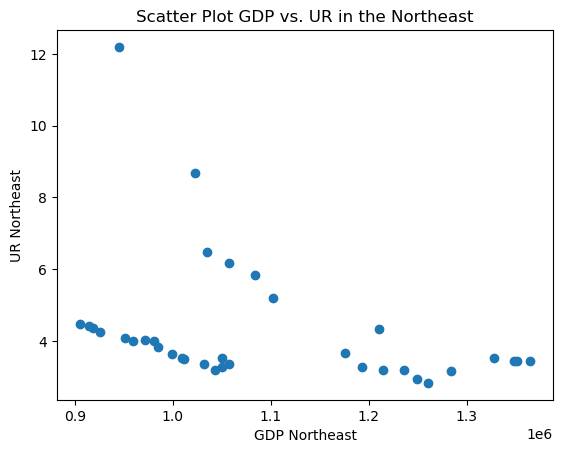

In [233]:
plt.scatter(df['GDP_Northeast'], df['UR_Northeast'])
plt.title("Scatter Plot GDP vs. UR in the Northeast")
plt.xlabel('GDP Northeast')
plt.ylabel('UR Northeast')
plt.show()

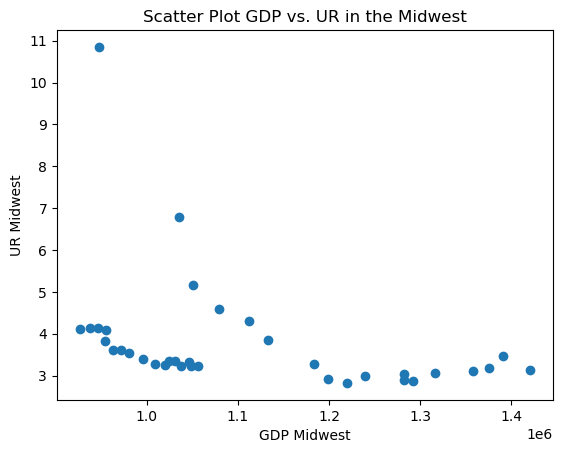

In [235]:
plt.scatter(df['GDP_Midwest'], df['UR_Midwest'])
plt.title("Scatter Plot GDP vs. UR in the Midwest")
plt.xlabel('GDP Midwest')
plt.ylabel('UR Midwest')
plt.show()

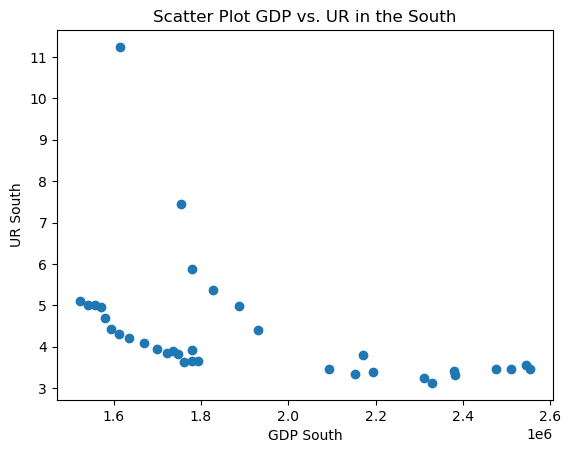

In [237]:
plt.scatter(df['GDP_South'], df['UR_South'])
plt.title("Scatter Plot GDP vs. UR in the South")
plt.xlabel('GDP South')
plt.ylabel('UR South')
plt.show()

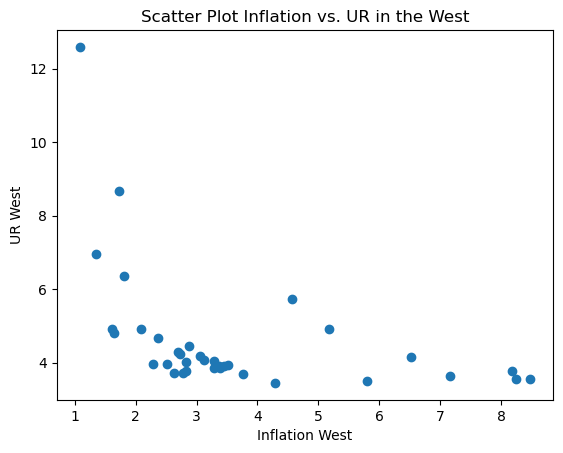

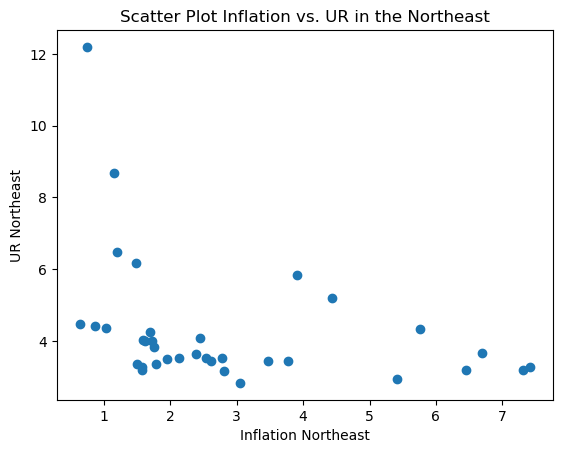

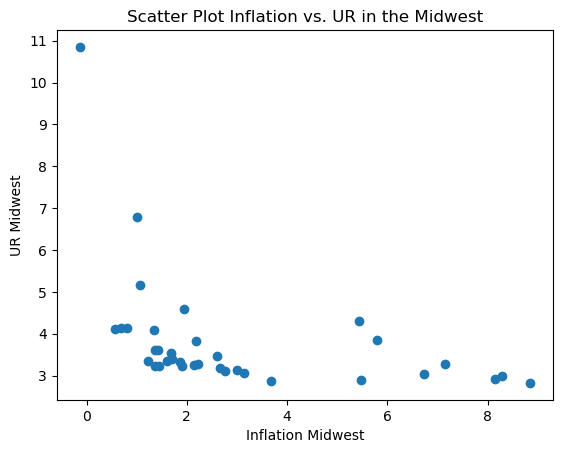

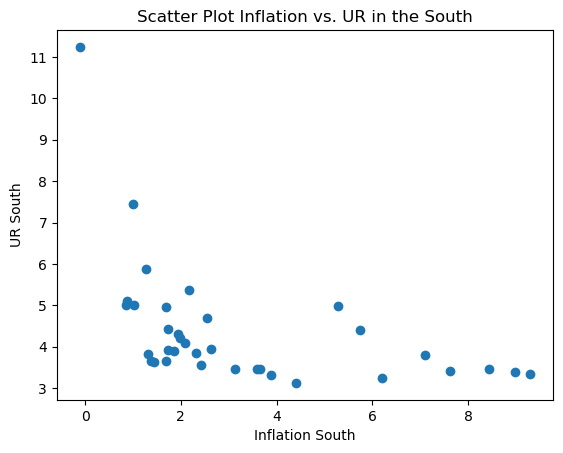

In [241]:
# GDP tends to grow over time, so this picture is not necessarily helpful, except to compare how high inflation
# can get in different areas.  

# Inflation and unemployment are supposedly negatively related so I'm interested to see those pictures.
plt.scatter(df['Inflation_W'], df['UR_West'])
plt.title("Scatter Plot Inflation vs. UR in the West")
plt.xlabel('Inflation West')
plt.ylabel('UR West')
plt.show()

plt.scatter(df['Inflation_NE'], df['UR_Northeast'])
plt.title("Scatter Plot Inflation vs. UR in the Northeast")
plt.xlabel('Inflation Northeast')
plt.ylabel('UR Northeast')
plt.show()

plt.scatter(df['Inflation_MW'], df['UR_Midwest'])
plt.title("Scatter Plot Inflation vs. UR in the Midwest")
plt.xlabel('Inflation Midwest')
plt.ylabel('UR Midwest')
plt.show()

plt.scatter(df['Inflation_S'], df['UR_South'])
plt.title("Scatter Plot Inflation vs. UR in the South")
plt.xlabel('Inflation South')
plt.ylabel('UR South')
plt.show()

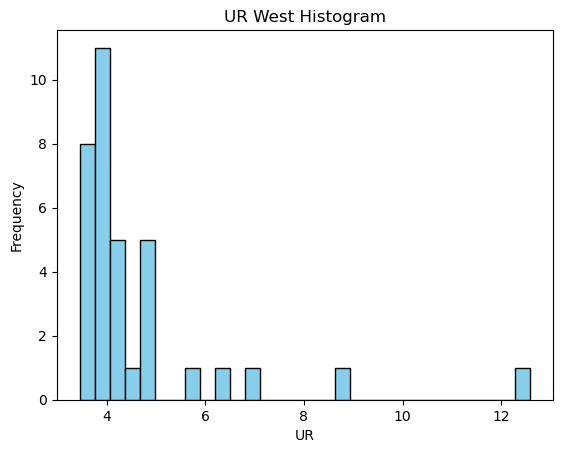

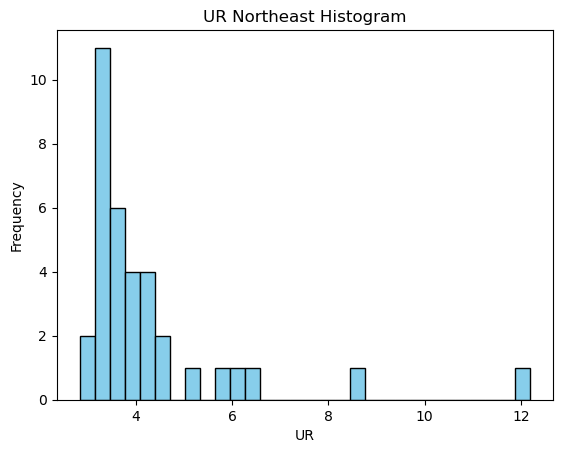

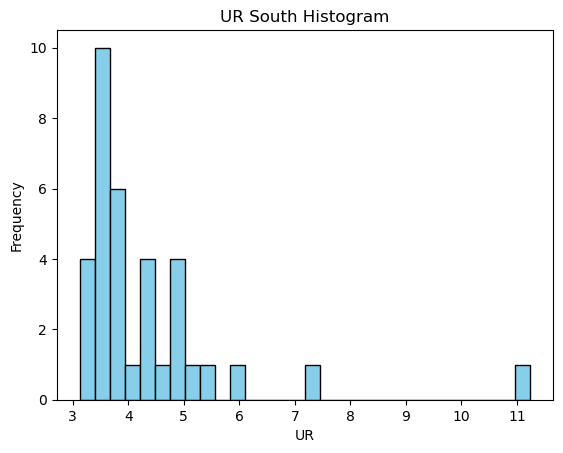

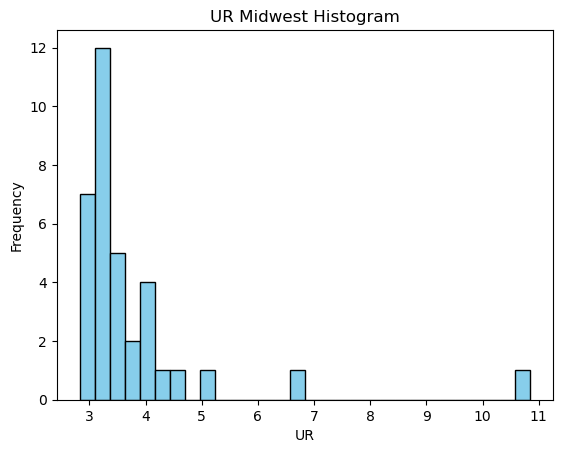

In [245]:
# From these, it seems the Midwest is more insulated from high unemployment rates for some reason, the South
# also is, to a lesser degree.  

# To further explore this, I'll look at histograms of the unemployment rate in each area.

plt.hist(df['UR_West'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('UR')
plt.ylabel('Frequency')
plt.title('UR West Histogram')
plt.show()

plt.hist(df['UR_Northeast'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('UR')
plt.ylabel('Frequency')
plt.title('UR Northeast Histogram')
plt.show()

plt.hist(df['UR_South'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('UR')
plt.ylabel('Frequency')
plt.title('UR South Histogram')
plt.show()

plt.hist(df['UR_Midwest'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('UR')
plt.ylabel('Frequency')
plt.title('UR Midwest Histogram')
plt.show()

In [247]:
# This seems to confirm that the Midwest and South have lower spikes in unemployment when it does rise.

In [ ]:
#During this class, I learned how to obtain data from various sources, how to keep API keys hidden, and struggled 
#through various obstacles ranging from simple but infuriating (figuring out a data set was a string instead of a 
#data frame) to interesting revelations (finally figuring out how to make tables in SQL which seemed 
#straightforward once I realized what I was doing wrong).  One thing I’m happy to be learning is through 
#repetition actually remembering the formatting that should be used an/or being able to fix an error almost 
#immediately most of the time when it pops up.  Specifically for this milestone, I learned how well datetime 
#indexes work, especially when used with SQL tables.  I also learned how much data cleaning there can still be 
#left to be even after you have your data looking good just to get them to cooperate.   

#At certain points, it probably would have been much easier to just copy and paste and do it manually, but I got 
#an appreciation for accomplishing this data cleaning with an automated process that could be done in a minute or 
#two instead of having to manually fix the data every time you wanted to process it.  This would also be much 
#easier than having to manually manipulate much larger data sets than the ones I worked with.  

#In the most recent milestone, I had to condense two of the data sets to regions instead of state by state, and 
#had to do a lot of work on the inflation rate data set, since it was organized by month in columns and years in 
#rows.  There may have been an easier way to accomplish it, but I got it sorted without resorting to exporting it 
#as comma separated values and reshaping it.  My biggest problem which ended up being resolved when putting the 
#data into the SQL tables was that the GDP data set required me to set an index inappropriately (it was showing 
#up as an object and turned everything into objects if I transposed the data set while it was not the index).  
#In the end I just renamed it when importing it as a table and everything worked out, but I have no idea what was 
#happening there.  

#As before, there’s not legal or regulatory guidelines for my project, as all the information is publicly 
#available from the government.  My biggest concerns were that the data wouldn’t line up properly but the 
#datetime columns did actually work to correct the data not lining up, as far as I know.  My biggest assumption 
#when transforming the data was how I decided to squish the data from monthly to quarterly.  I assumed it was the 
#average over the quarter, although you may want to center it on the first month of a quarter instead of taking 
#the average over the quarter.  I do not believe there are any ethical concerns with my project.  


In [280]:
print(df)

                   date  GDP_United States      GDP_West   GDP_Midwest  \
0   2016-01-01 00:00:00         4553110.00  1.137880e+06  9.262662e+05   
1   2016-04-01 00:00:00         4606297.50  1.152171e+06  9.375755e+05   
2   2016-07-01 00:00:00         4654005.00  1.168951e+06  9.470198e+05   
3   2016-10-01 00:00:00         4698089.00  1.183426e+06  9.555690e+05   
4   2017-01-01 00:00:00         4790637.50  1.207327e+06  9.546817e+05   
..                  ...                ...           ...           ...   
65  2024-04-01 00:00:00         7254178.50  1.874653e+06  1.375563e+06   
66  2024-07-01 00:00:00         7343728.50  1.897657e+06  1.390426e+06   
67  2021-10-01 00:00:00         6319698.75  1.633678e+06  1.182968e+06   
68  2022-10-01 00:00:00         6815883.75  1.787279e+06  1.281729e+06   
69  2023-10-01 00:00:00         7349023.75  1.876635e+06  1.420915e+06   

       GDP_South  GDP_Northeast                 date   UR_West  UR_Midwest  \
0   1.521954e+06   9.047042e+05  